# 3 — Real Materials

This notebook demonstrates wavelength-dependent refractive indices in DiffTMM.

The new `Material` class loads dispersive refractive-index data from bundled catalogs:
- AGF glass catalogs (CDGM, SCHOTT, MISC, PLASTIC) — Sellmeier coefficients for hundreds of optical glasses
- DeepLens `materials_data.json` — additional custom Sellmeier / interpolation entries
- `thin_film_materials.json` — n+k tables for common thin-film materials (SiO₂, TiO₂, Ag, …)

Solvers accept materials by name (string), by `Material` instance, or as scalar/complex constants — mixable per layer.

In [1]:
import torch
import matplotlib.pyplot as plt

from difftmm import IsotropicFilmSolver, Material, list_materials

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"{len(list_materials())} known materials")

Using device: cuda
662 known materials


## 1. Plot n(λ), k(λ) for real materials

Real materials have wavelength-dependent refractive index `n` (real part) and extinction coefficient `k` (imaginary part). Below we plot the visible-light response for a dielectric (SiO₂), a high-index semiconductor (TiO₂), and a metal (silver).

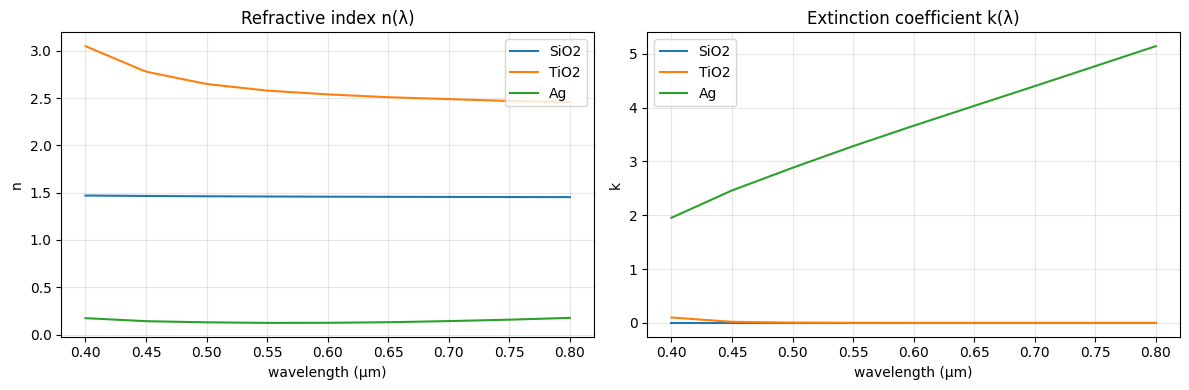

In [2]:
wvln = torch.linspace(0.40, 0.80, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name in ["SiO2", "TiO2", "Ag"]:
    mat = Material(name, device=device)
    n = mat.ior(wvln.to(device)).cpu()
    ax1.plot(wvln.numpy(), n.real.numpy(), label=name)
    ax2.plot(wvln.numpy(), n.imag.numpy(), label=name)
ax1.set_xlabel("wavelength (μm)"); ax1.set_ylabel("n")
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_title("Refractive index n(λ)")
ax2.set_xlabel("wavelength (μm)"); ax2.set_ylabel("k")
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_title("Extinction coefficient k(λ)")
plt.tight_layout(); plt.show()

## 2. Anti-reflection coating broadband reflectance

A two-layer anti-reflection (AR) coating uses a high-index/low-index stack to minimize reflection at a target wavelength. We use TiO₂ (high index) and SiO₂ (low index) on an N-BK7 substrate.

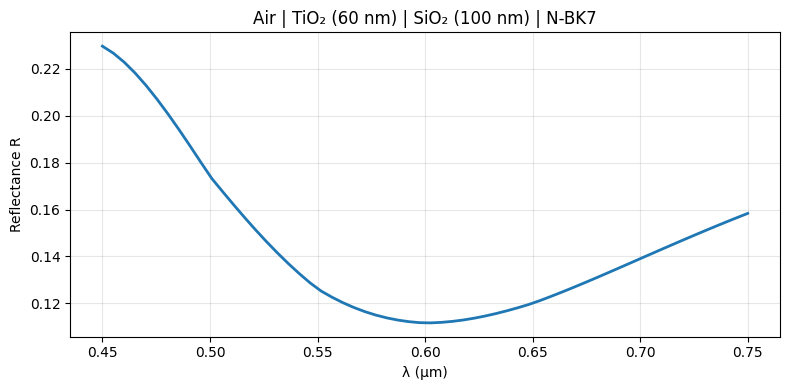

In [3]:
solver = IsotropicFilmSolver(
    mat_in="air",
    mat_out="N-BK7",
    mat_ls=["TiO2", "SiO2"],
    thickness_ls=[0.06, 0.10],
    device=device,
)
wvln = torch.linspace(0.45, 0.75, 60).to(device)
theta = torch.tensor([0.0], device=device)
ts, tp, rs, rp = solver.simulate(theta=theta, wvln=wvln)
R = (rs.abs() ** 2).squeeze().cpu()

plt.figure(figsize=(8, 4))
plt.plot(wvln.cpu().numpy(), R.numpy(), linewidth=2)
plt.xlabel("λ (μm)"); plt.ylabel("Reflectance R")
plt.title("Air | TiO₂ (60 nm) | SiO₂ (100 nm) | N-BK7")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 3. Surface plasmon resonance (SPR) with silver

The Kretschmann configuration excites surface plasmons at a metal/dielectric interface. We sweep the angle at 633 nm through a 50 nm silver film deposited on a glass prism. The reflection dip indicates plasmon excitation — driven by silver's large imaginary refractive index in the visible.

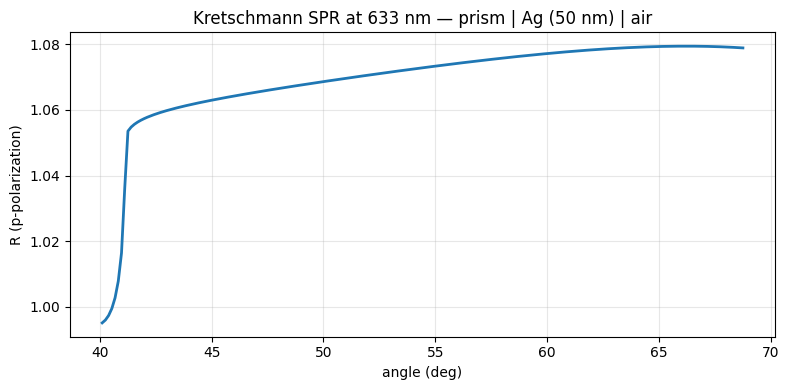

In [4]:
solver = IsotropicFilmSolver(
    mat_in=1.52,           # prism
    mat_out="air",
    mat_ls=["Ag"],
    thickness_ls=[0.05],     # 50 nm Ag
    device=device,
)
theta = torch.linspace(0.7, 1.2, 200).to(device)  # ~40-70 deg
wvln = torch.tensor([0.633], device=device)
_, _, _, rp = solver.simulate(theta=theta, wvln=wvln)
R_p = (rp.abs() ** 2).squeeze().cpu()

plt.figure(figsize=(8, 4))
plt.plot(theta.cpu().numpy() * 180 / 3.141592653589793, R_p.numpy(), linewidth=2)
plt.xlabel("angle (deg)"); plt.ylabel("R (p-polarization)")
plt.title("Kretschmann SPR at 633 nm — prism | Ag (50 nm) | air")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()